# jj local $Y_{\ell m}$ tower validation (Chunk C)

Validates the per-$m$ LOCAL-current $Y_{\ell m}$ tower: stochastic CONN (`jj_local_ylm_conn_stoch`) and
DISC + $\sigma_{PS}$ (`jj_local_ylm_disc_stoch`) against the deterministic ground truth
`jj_local_deter` (`corr_deter_local_ylmA_L1`).  Free field, L=1.

- **CONN**: hit-averaged stoch $g^a_{\ell m}\to$ determ; tp$=s_3$ ($G_t$), sp$=(s_1+s_2)/2$ ($G_s$);
  $g^a_\ell=\frac{1}{2\ell+1}\sum_m g^a_{\ell m}$.
- **DISC**: $C_{\rm disc},\ell=\frac{1}{2\ell+1}\sum_m$ two_point(hit-avg $J^a_{\ell m}$) $\to 0$ in free.
- **CONDENSATE**: $\sigma_{PS}\to -2$.

CFT reference (continuum, Eq.4.35; `jj_cft_ylm_check`): $G^t_1\to e^{-2t}/(24\pi^2)$, $G^t_2\to e^{-3t}/(10\pi^2)$,
ratio $g_2 e^{3t}/g_1 e^{2t}\to 12/5=2.4$, where $t=a_t\,n_t$ ($a_t=0.2$).  **At L=1 the lattice tower is
aliased**, so it need NOT sit on the CFT curves -- the real validation is stoch vs determ; the CFT curves
are drawn as the continuum reference (they are approached only as $L$ grows / with the continuum prop).

In [19]:
import h5py, numpy as np, glob, math
import matplotlib.pyplot as plt

D = "data_free_vmRe0.000000vmIm0.000000/"
Nt = 128
at = 0.2                      # temporal lattice spacing; conformal time t = at * dt
sumA = 4.0*math.pi            # sum_n dual_areas = unit-sphere area
L_MAX = 3

det_file   = D + "corr_deter_local_ylmA_L1/corr.0.h5"
conn_files = sorted(glob.glob(D + "corr_ylm_conn_t00_nhits*_s1/corr.0.h*.h5"))
disc_files = sorted(glob.glob(D + "corr_ylm_disc_tb8_nhits*/corr.0.h*.h5"))
print("determ:", det_file)
print("conn hits:", len(conn_files), "  disc hits:", len(disc_files))

determ: data_free_vmRe0.000000vmIm0.000000/corr_deter_local_ylmA_L1/corr.0.h5
conn hits: 16   disc hits: 16


In [20]:
# ---- loaders (determ Vpp already inv4pi-folded; stoch conn Vpp uses the SAME fold) ----
def det_vpp(chan, l, m):
    with h5py.File(det_file, "r") as f:
        k = f"h0/t0_0/ylm/{chan}/l{l}/m{m}/Vpp"
        return f[k+"/real"][()] + 1j*f[k+"/imag"][()]

def det_samesite(chan):                 # bare same-site local channel (NOT ylm-projected): full G_t/G_s
    with h5py.File(det_file, "r") as f:
        k = f"h0/t0_0/{chan}/Vpp"
        return f[k+"/real"][()] + 1j*f[k+"/imag"][()]

def conn_hits(chan, l, m):              # (H, Nt) complex, per hit
    out = []
    for fn in conn_files:
        with h5py.File(fn, "r") as f:
            k = f"h0/ylm/{chan}/l{l}/m{m}/Vpp"
            out.append(f[k+"/real"][()] + 1j*f[k+"/imag"][()])
    return np.array(out)

def disc_hits(chan, l, m):              # (H, Nt) complex RAW J(t), per hit
    out = []
    for fn in disc_files:
        with h5py.File(fn, "r") as f:
            k = f"h0/disc/ylm/{chan}/l{l}/m{m}/J"
            out.append(f[k+"/real"][()] + 1j*f[k+"/imag"][()])
    return np.array(out)

def cond_hits():
    out = []
    for fn in disc_files:
        with h5py.File(fn, "r") as f:
            out.append(f["h0/condensate/etadag_xi/real"][0] + 1j*f["h0/condensate/etadag_xi/imag"][0])
    return np.array(out)

# delete-1 jackknife over the hit axis -> (mean, err_re, err_im)
def jackknife(samp):
    H = samp.shape[0]
    jk = (samp.sum(0) - samp) / (H - 1)
    mean = samp.mean(0)
    ere = np.sqrt(np.maximum((H-1)*np.mean((jk.real-mean.real)**2, 0), 0.0))
    eim = np.sqrt(np.maximum((H-1)*np.mean((jk.imag-mean.imag)**2, 0), 0.0))
    return mean, ere, eim

def gl_det(chan, l):                    # (1/(2l+1)) sum_m, determ
    return sum(det_vpp(chan,l,m) for m in range(-l,l+1)) / (2*l+1)
def gl_conn_hits(chan, l):              # (H, Nt) l-summed per hit
    return sum(conn_hits(chan,l,m) for m in range(-l,l+1)) / (2*l+1)

# CFT same-site G_t shape (Eq. 4.31) and amplitude Cj matched from the bare s3 same-site correlator.
def cft_shape(t):
    return np.exp(-2.0*t) * (1.0 - np.exp(-t))**(-4.0)
dt_full = np.arange(1, Nt//2)
t_full  = dt_full * at
_gt_ss  = det_samesite('s3').real            # G_t same-site (Re < 0)
REF = 5
Cj = -_gt_ss[REF] / cft_shape(REF*at)        # > 0 ; |Cj| -> 1/(8pi^2) in the continuum
print(f"Cj (matched from s3 same-site) = {Cj:.5e}   (1/(8pi^2) = {1/(8*math.pi**2):.5e})")

Cj (matched from s3 same-site) = 4.87230e-04   (1/(8pi^2) = 1.26651e-02)


## CONN: stochastic (hit-averaged) vs deterministic tower, with CFT curves

(1e-10, 0.01)

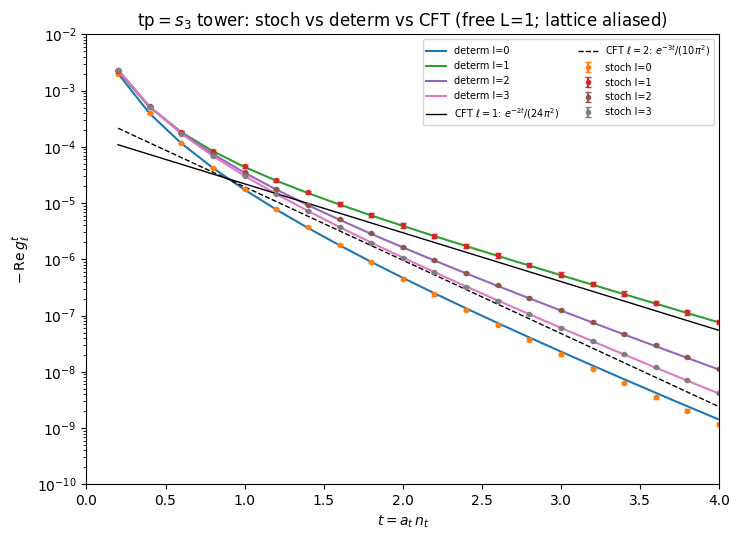

In [21]:
# tp = s3 tower: determ (lines) vs stoch (points) vs CFT curves (dashed).  -Re g_l on log; t = at*dt.
fig, ax = plt.subplots(figsize=(7.5,5.5))
for l in (0,1,2,3):
    d = gl_det('s3', l).real
    s, sre, _ = jackknife(gl_conn_hits('s3', l))
    ax.plot(t_full, -d[dt_full], '-', label=f'determ l={l}')
    ax.errorbar(t_full, -s.real[dt_full], yerr=sre[dt_full], fmt='o', ms=3, capsize=2, label=f'stoch l={l}')
# CFT continuum references (Eq.4.35): g^t_1 ~ (1/3)Cj e^{-2t} = e^{-2t}/(24pi^2); g^t_2 ~ (4/5)Cj e^{-3t}
ax.plot(t_full, (1.0/3.0)*Cj*np.exp(-2.0*t_full), 'k-',  lw=1, label=r'CFT $\ell=1$: $e^{-2t}/(24\pi^2)$')
ax.plot(t_full, (4.0/5.0)*Cj*np.exp(-3.0*t_full), 'k--', lw=1, label=r'CFT $\ell=2$: $e^{-3t}/(10\pi^2)$')
ax.set_yscale('log'); ax.set_xlim(0, 4.0)
ax.set_xlabel(r'$t = a_t\, n_t$'); ax.set_ylabel(r'$-\,\mathrm{Re}\,g^t_\ell$')
ax.set_title(r'tp$=s_3$ tower: stoch vs determ vs CFT (free L=1; lattice aliased)')
ax.legend(ncol=2, fontsize=7); plt.tight_layout()

ax.set_ylim(1.0e-10, 1.0e-2)

(1e-10, 0.01)

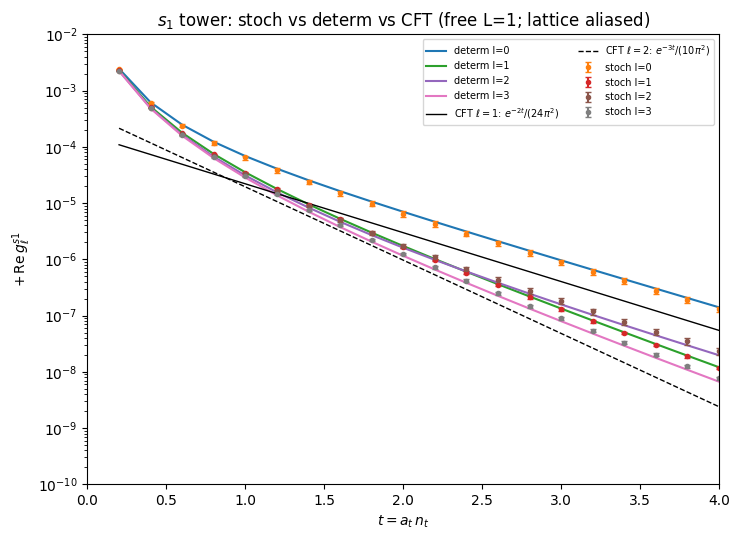

In [22]:
# s1 tower: determ (lines) vs stoch (points) vs CFT curves.  +Re g_l on log (s1 > 0); t = at*dt.
fig, ax = plt.subplots(figsize=(7.5,5.5))
for l in (0,1,2,3):
    d = gl_det('s1', l).real
    s, sre, _ = jackknife(gl_conn_hits('s1', l))
    ax.plot(t_full, d[dt_full], '-', label=f'determ l={l}')
    ax.errorbar(t_full, s.real[dt_full], yerr=sre[dt_full], fmt='o', ms=3, capsize=2, label=f'stoch l={l}')
# CFT continuum references: g^s_l = -g^t_l (sp/tp -> -1), so s1 ~ +(1/3)Cj e^{-2t}, +(4/5)Cj e^{-3t}
ax.plot(t_full, (1.0/3.0)*Cj*np.exp(-2.0*t_full), 'k-',  lw=1, label=r'CFT $\ell=1$: $e^{-2t}/(24\pi^2)$')
ax.plot(t_full, (4.0/5.0)*Cj*np.exp(-3.0*t_full), 'k--', lw=1, label=r'CFT $\ell=2$: $e^{-3t}/(10\pi^2)$')
ax.set_yscale('log'); ax.set_xlim(0, 4.0)
ax.set_xlabel(r'$t = a_t\, n_t$'); ax.set_ylabel(r'$+\,\mathrm{Re}\,g^{s1}_\ell$')
ax.set_title(r'$s_1$ tower: stoch vs determ vs CFT (free L=1; lattice aliased)')
ax.legend(ncol=2, fontsize=7); plt.tight_layout()

ax.set_ylim(1.0e-10, 1.0e-2)

(1e-10, 0.01)

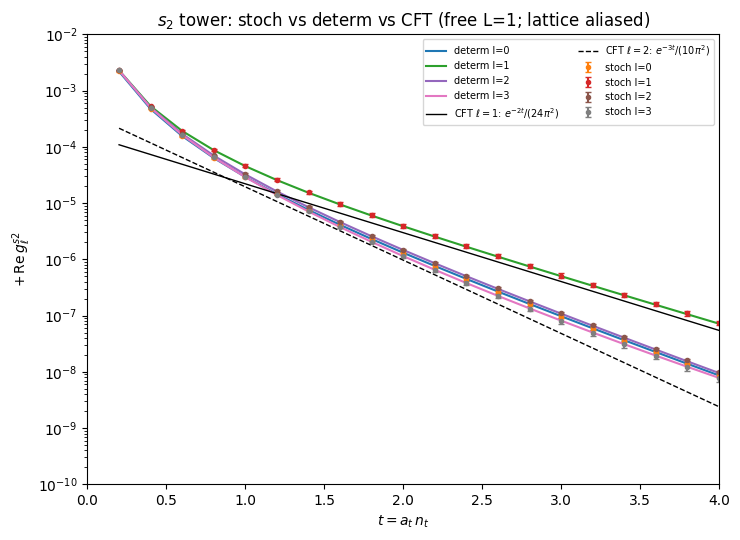

In [23]:
# s2 tower: determ (lines) vs stoch (points) vs CFT curves.  +Re g_l on log (s2 > 0); t = at*dt.
# (s2 = s1 in free; for interacting / finite-L they can differ -- kept separate as a diagnostic.)
fig, ax = plt.subplots(figsize=(7.5,5.5))
for l in (0,1,2,3):
    d = gl_det('s2', l).real
    s, sre, _ = jackknife(gl_conn_hits('s2', l))
    ax.plot(t_full, d[dt_full], '-', label=f'determ l={l}')
    ax.errorbar(t_full, s.real[dt_full], yerr=sre[dt_full], fmt='o', ms=3, capsize=2, label=f'stoch l={l}')
# CFT continuum references: g^s_l = -g^t_l (sp/tp -> -1), so s2 ~ +(1/3)Cj e^{-2t}, +(4/5)Cj e^{-3t}
ax.plot(t_full, (1.0/3.0)*Cj*np.exp(-2.0*t_full), 'k-',  lw=1, label=r'CFT $\ell=1$: $e^{-2t}/(24\pi^2)$')
ax.plot(t_full, (4.0/5.0)*Cj*np.exp(-3.0*t_full), 'k--', lw=1, label=r'CFT $\ell=2$: $e^{-3t}/(10\pi^2)$')
ax.set_yscale('log'); ax.set_xlim(0, 4.0)
ax.set_xlabel(r'$t = a_t\, n_t$'); ax.set_ylabel(r'$+\,\mathrm{Re}\,g^{s2}_\ell$')
ax.set_title(r'$s_2$ tower: stoch vs determ vs CFT (free L=1; lattice aliased)')
ax.legend(ncol=2, fontsize=7); plt.tight_layout()

ax.set_ylim(1.0e-10, 1.0e-2)

## AXIAL $Y_{\ell m}$ tower (no GW dressing)

Local axial = the local vector with the $t_0$-leg propagator **forward** ($D_m^{-1}$) instead of backward
($D_m^{-\dagger}$); bare $\sigma_a$ vertex, **no** $(1-D_{ov})$ GW factor (modeled on the local axial in
`jj_corr_dilute_claude.cu`). It estimates $\mathrm{tr}[\Sigma_0\,P^\dagger\Sigma_t\,P]$ (one dagger) vs the
vector $\mathrm{tr}[\Sigma_0 P\Sigma_t P]$. HDF5 keys `ylm_axial/s{a}/l{l}/m{m}`. Validation: hit-averaged
stoch $\to$ determ (same as vector).  **Requires the rebuilt `jj_local_deter` + `jj_local_ylm_conn_stoch`
runs** (which now also write `ylm_axial`). No axial disc (the one-point loop is vertex-only = vector).

In [24]:
# axial loaders (read ylm_axial; same structure as the vector ones).  Requires the rebuilt determ + conn
# runs that write h0/.../ylm_axial/... (rerun jj_local_deter + jj_local_ylm_conn_stoch after the rebuild).
def det_vpp_ax(chan, l, m):
    with h5py.File(det_file, "r") as f:
        k = f"h0/t0_0/ylm_axial/{chan}/l{l}/m{m}/Vpp"
        return f[k+"/real"][()] + 1j*f[k+"/imag"][()]
def conn_hits_ax(chan, l, m):
    out = []
    for fn in conn_files:
        with h5py.File(fn, "r") as f:
            k = f"h0/ylm_axial/{chan}/l{l}/m{m}/Vpp"
            out.append(f[k+"/real"][()] + 1j*f[k+"/imag"][()])
    return np.array(out)
def gl_det_ax(chan, l):
    return sum(det_vpp_ax(chan,l,m) for m in range(-l,l+1)) / (2*l+1)
def gl_conn_hits_ax(chan, l):
    return sum(conn_hits_ax(chan,l,m) for m in range(-l,l+1)) / (2*l+1)

(1e-10, 0.01)

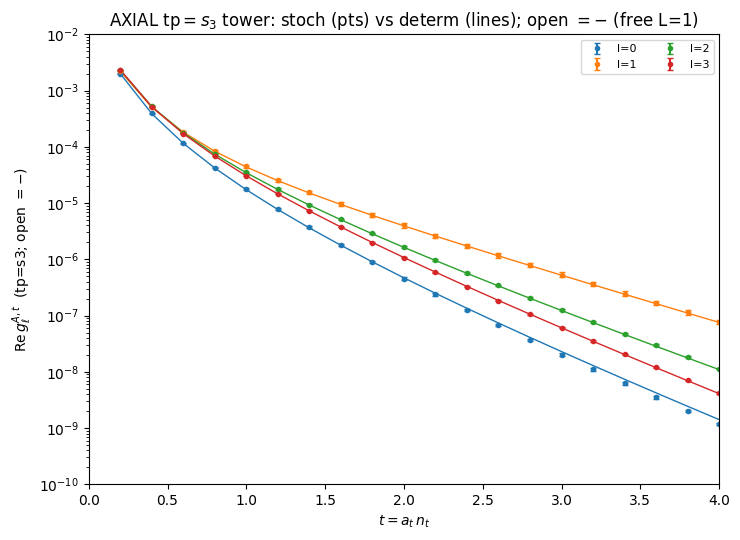

In [25]:
# AXIAL tp = s3 tower: signed-log, stoch (+ filled / - open, jackknife err) vs determ (+ solid / - dotted).
chan = 's3'
fig, ax = plt.subplots(figsize=(7.5,5.5))
for l in (0,1,2,3):
    c = f'C{l}'
    yd = gl_det_ax(chan, l).real[dt_full]
    ys_, es, _ = jackknife(gl_conn_hits_ax(chan, l)); ys = ys_.real[dt_full]; es = es[dt_full]
    pd = yd > 0; nd = yd < 0
    ax.plot(t_full[pd],  yd[pd], '-', color=c, lw=1)
    ax.plot(t_full[nd], -yd[nd], ':', color=c, lw=1)
    ps = ys > 0; ns = ys < 0
    ax.errorbar(t_full[ps],  ys[ps], yerr=es[ps], fmt='o', ms=3, capsize=2, color=c, label=f'l={l}')
    ax.errorbar(t_full[ns], -ys[ns], yerr=es[ns], fmt='v', ms=3, capsize=2, color=c, mfc='none')
ax.set_yscale('log'); ax.set_xlim(0, 4.0)
ax.set_xlabel(r'$t = a_t\, n_t$'); ax.set_ylabel(r'$\mathrm{Re}\,g^{A,t}_\ell$  (tp=s3; open $=-$)')
ax.set_title(r'AXIAL tp$=s_3$ tower: stoch (pts) vs determ (lines); open $=-$ (free L=1)')
ax.legend(ncol=2, fontsize=8); plt.tight_layout()

ax.set_ylim(1.0e-10, 1.0e-2)

(1e-10, 0.01)

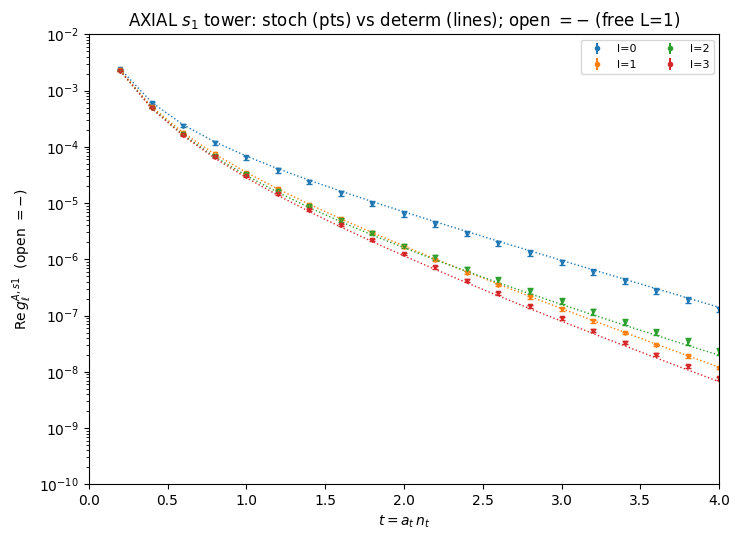

In [26]:
# AXIAL s1 tower: signed-log, stoch (+ filled / - open, jackknife err) vs determ (+ solid / - dotted).
chan = 's1'
fig, ax = plt.subplots(figsize=(7.5,5.5))
for l in (0,1,2,3):
    c = f'C{l}'
    yd = gl_det_ax(chan, l).real[dt_full]
    ys_, es, _ = jackknife(gl_conn_hits_ax(chan, l)); ys = ys_.real[dt_full]; es = es[dt_full]
    pd = yd > 0; nd = yd < 0
    ax.plot(t_full[pd],  yd[pd], '-', color=c, lw=1)
    ax.plot(t_full[nd], -yd[nd], ':', color=c, lw=1)
    ps = ys > 0; ns = ys < 0
    ax.errorbar(t_full[ps],  ys[ps], yerr=es[ps], fmt='o', ms=3, capsize=2, color=c, label=f'l={l}')
    ax.errorbar(t_full[ns], -ys[ns], yerr=es[ns], fmt='v', ms=3, capsize=2, color=c, mfc='none')
ax.set_yscale('log'); ax.set_xlim(0, 4.0)
ax.set_xlabel(r'$t = a_t\, n_t$'); ax.set_ylabel(r'$\mathrm{Re}\,g^{A,s1}_\ell$  (open $=-$)')
ax.set_title(r'AXIAL $s_1$ tower: stoch (pts) vs determ (lines); open $=-$ (free L=1)')
ax.legend(ncol=2, fontsize=8); plt.tight_layout()

ax.set_ylim(1.0e-10, 1.0e-2)

(1e-10, 0.01)

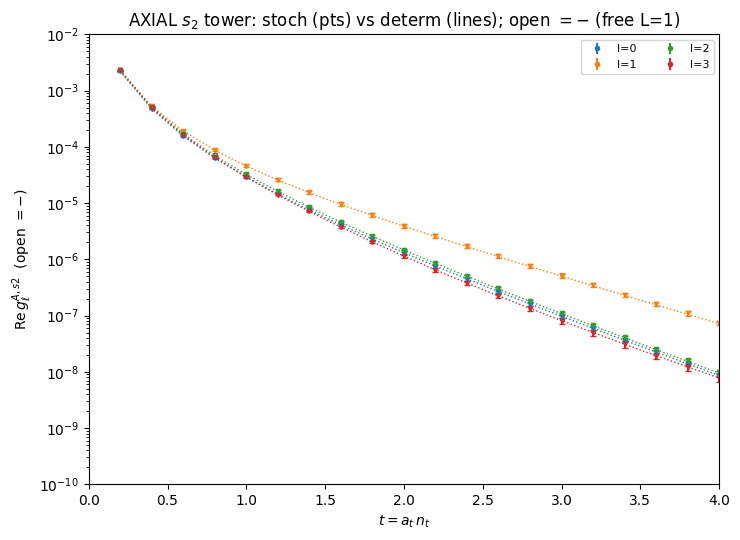

In [27]:
# AXIAL s2 tower: signed-log, stoch (+ filled / - open, jackknife err) vs determ (+ solid / - dotted).
chan = 's2'
fig, ax = plt.subplots(figsize=(7.5,5.5))
for l in (0,1,2,3):
    c = f'C{l}'
    yd = gl_det_ax(chan, l).real[dt_full]
    ys_, es, _ = jackknife(gl_conn_hits_ax(chan, l)); ys = ys_.real[dt_full]; es = es[dt_full]
    pd = yd > 0; nd = yd < 0
    ax.plot(t_full[pd],  yd[pd], '-', color=c, lw=1)
    ax.plot(t_full[nd], -yd[nd], ':', color=c, lw=1)
    ps = ys > 0; ns = ys < 0
    ax.errorbar(t_full[ps],  ys[ps], yerr=es[ps], fmt='o', ms=3, capsize=2, color=c, label=f'l={l}')
    ax.errorbar(t_full[ns], -ys[ns], yerr=es[ns], fmt='v', ms=3, capsize=2, color=c, mfc='none')
ax.set_yscale('log'); ax.set_xlim(0, 4.0)
ax.set_xlabel(r'$t = a_t\, n_t$'); ax.set_ylabel(r'$\mathrm{Re}\,g^{A,s2}_\ell$  (open $=-$)')
ax.set_title(r'AXIAL $s_2$ tower: stoch (pts) vs determ (lines); open $=-$ (free L=1)')
ax.legend(ncol=2, fontsize=8); plt.tight_layout()

ax.set_ylim(1.0e-10, 1.0e-2)

In [28]:
# # tp tower stoch/determ ratio -> 1 (the per-m fix; NOT 4).  Small dt where signal > noise.
# fig, ax = plt.subplots(figsize=(7,5))
# tt = np.arange(1, 11)
# for l in (0,1,2,3):
#     r = gl_conn_hits('s3', l).real / gl_det('s3', l).real[None,:]
#     m, ere, _ = jackknife(r)
#     ax.errorbar(tt, m[tt], yerr=ere[tt], fmt='o-', ms=3, capsize=2, label=f'l={l}')
# ax.axhline(1.0, color='k', ls='--', lw=0.8)
# ax.set_xlabel('dt'); ax.set_ylabel('stoch / determ  (tp=s3)')
# ax.set_title('CONN tp tower: stoch/determ -> 1'); ax.legend(); plt.tight_layout()

In [29]:
# # CFT amplitude ratio g2 e^{3t}/g1 e^{2t} -> 12/5 = 2.4 (determ + stoch).  (L=1 lattice is aliased -> off 2.4.)
# fig, ax = plt.subplots(figsize=(7,5))
# g1d = gl_det('s3',1).real; g2d = gl_det('s3',2).real
# ratio_d = (g2d[dt_full]*np.exp(3.0*t_full)) / (g1d[dt_full]*np.exp(2.0*t_full))
# ax.plot(t_full, ratio_d, 's-', ms=3, label='determ')
# g1h = gl_conn_hits('s3',1); g2h = gl_conn_hits('s3',2)
# rr = (g2h.real*np.exp(3.0*at*np.arange(Nt))[None,:]) / (g1h.real*np.exp(2.0*at*np.arange(Nt))[None,:])
# m, ere, _ = jackknife(rr)
# ax.errorbar(t_full, m[dt_full], yerr=ere[dt_full], fmt='o', ms=3, capsize=2, label='stoch')
# ax.axhline(12.0/5.0, color='k', ls='--', lw=0.8, label=r'CFT $12/5=2.4$')
# ax.set_xlim(0,4.0); ax.set_ylim(0,5)
# ax.set_xlabel(r'$t = a_t\, n_t$'); ax.set_ylabel(r'$g_2 e^{3t}/g_1 e^{2t}$')
# ax.set_title(r'CFT amplitude ratio $\to 2.4$ (L=1 aliased)'); ax.legend(); plt.tight_layout()

In [30]:
# # sp/tp ratio -> -1 (determ and stoch), per l.  sp = (s1+s2)/2.
# fig, ax = plt.subplots(figsize=(7,5))
# tt = np.arange(1, 11)
# for l in (0,1,2,3):
#     sp_d = (gl_det('s1',l) + gl_det('s2',l)).real/2
#     tp_d = gl_det('s3',l).real
#     ax.plot(tt, (sp_d/tp_d)[tt], 's-', ms=3, label=f'determ l={l}')
#     sp_h = (gl_conn_hits('s1',l) + gl_conn_hits('s2',l))/2
#     m, ere, _ = jackknife(sp_h.real / gl_conn_hits('s3',l).real)
#     ax.errorbar(tt, m[tt], yerr=ere[tt], fmt='o', ms=3, capsize=2, label=f'stoch l={l}')
# ax.axhline(-1.0, color='k', ls='--', lw=0.8)
# ax.set_xlabel('dt'); ax.set_ylabel('sp / tp'); ax.set_ylim(-1.6,-0.4)
# ax.set_title('CONN sp/tp -> -1'); ax.legend(ncol=2, fontsize=8); plt.tight_layout()

## DISC: $C_{\rm disc}\to 0$ in free

$C_{\rm disc},\ell=\frac{1}{2\ell+1}\sum_m$ two_point(hit-avg $J^a_{\ell m}$).  True value $0$ in free; at
finite hits it sits at the stochastic noise floor ($\propto 1/H$).  $s_1/s_2$ are pure off-diagonal noise
(floor $\sim10^{-5}$ at 16 hits); $s_3$ much cleaner.

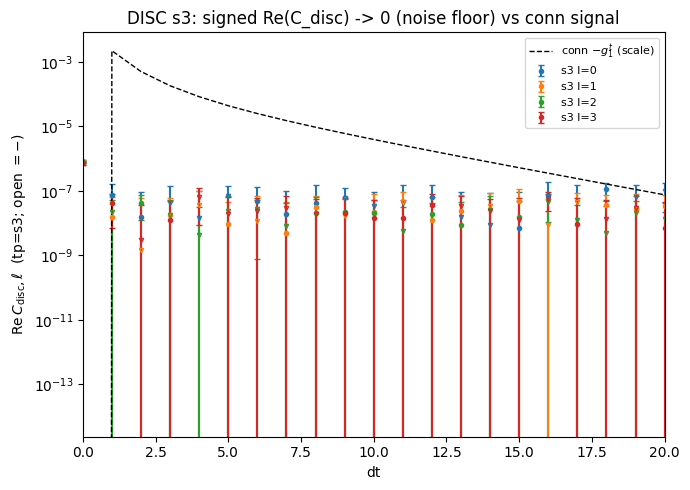

In [31]:
def two_point(J):
    G = np.zeros(Nt, dtype=complex)
    for dt in range(Nt):
        G[dt] = np.mean(J * np.conj(np.roll(J, -dt)))
    return G

# C_disc,l = (1/(2l+1)) sum_m two_point(hit-avg J).  Returns Re(C_disc) and its hit delete-1 jackknife
# error (each replicate drops one hit, re-averages J, re-does two_point + m-sum).  NO abs -> sign kept.
def Cdisc_l_jk(chan, l):
    H = len(disc_files)
    Jm = [disc_hits(chan,l,m) for m in range(-l,l+1)]            # each (H, Nt)
    full = sum(two_point(Jm_i.mean(0)) for Jm_i in Jm) / (2*l+1)
    rep = np.zeros((H, Nt))                                      # Re(C_disc) leave-one-out replicates
    for i in range(H):
        acc = sum(two_point((Jm_i.sum(0) - Jm_i[i])/(H-1)) for Jm_i in Jm) / (2*l+1)
        rep[i] = acc.real
    err = np.sqrt((H-1)*np.mean((rep - rep.mean(0))**2, 0))
    return full.real, err

# signed-log: + branch filled circles, - branch open triangles (same color per l); jackknife errorbars.
fig, ax = plt.subplots(figsize=(7,5))
dt = np.arange(Nt)
for l in (0,1,2,3):
    y, e = Cdisc_l_jk('s3', l)
    p = y > 0; n = y < 0
    ax.errorbar(dt[p],  y[p], yerr=e[p], fmt='o', ms=3, capsize=2, color=f'C{l}', label=f's3 l={l}')
    ax.errorbar(dt[n], -y[n], yerr=e[n], fmt='v', ms=3, capsize=2, color=f'C{l}', mfc='none')
ax.plot(dt, -gl_det('s3',1).real, 'k--', lw=1, label=r'conn $-g^t_1$ (scale)')
ax.set_yscale('log'); ax.set_xlim(0,20)
ax.set_xlabel('dt'); ax.set_ylabel(r'$\mathrm{Re}\,C_{\rm disc},\ell$  (tp=s3; open $=-$)')
ax.set_title('DISC s3: signed Re(C_disc) -> 0 (noise floor) vs conn signal'); ax.legend(fontsize=8); plt.tight_layout()

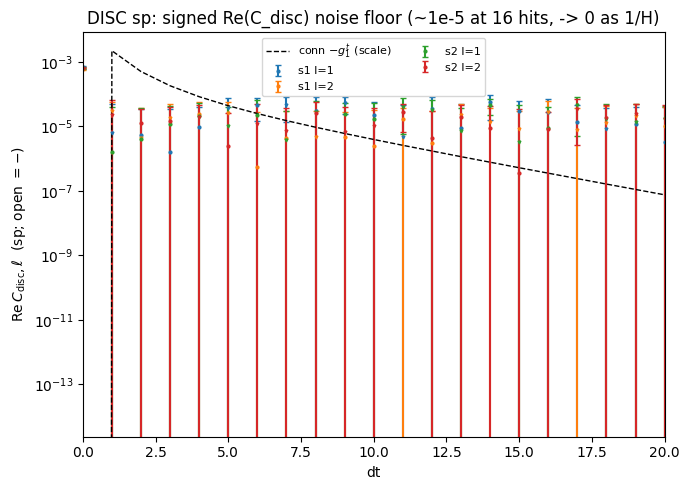

In [32]:
# disc s1/s2 (spatial): signed-log Re(C_disc,l) (+ filled / - open), jackknife errorbars.  Noise floor at 16 hits.
fig, ax = plt.subplots(figsize=(7,5))
dt = np.arange(Nt)
ci = 0
for chan in ('s1','s2'):
    for l in (1,2):
        y, e = Cdisc_l_jk(chan, l)
        p = y > 0; n = y < 0
        ax.errorbar(dt[p],  y[p], yerr=e[p], fmt='o', ms=2, capsize=2, color=f'C{ci}', label=f'{chan} l={l}')
        ax.errorbar(dt[n], -y[n], yerr=e[n], fmt='v', ms=2, capsize=2, color=f'C{ci}', mfc='none')
        ci += 1
ax.plot(dt, -gl_det('s3',1).real, 'k--', lw=1, label=r'conn $-g^t_1$ (scale)')
ax.set_yscale('log'); ax.set_xlim(0,20)
ax.set_xlabel('dt'); ax.set_ylabel(r'$\mathrm{Re}\,C_{\rm disc},\ell$  (sp; open $=-$)')
ax.set_title('DISC sp: signed Re(C_disc) noise floor (~1e-5 at 16 hits, -> 0 as 1/H)'); ax.legend(ncol=2, fontsize=8); plt.tight_layout()

## CONDENSATE $\sigma_{PS}$

$\sigma_{PS}=($etadag_xi$+$ c.c.$)/(N_t\sum_n A_n)\to -2$ in free (before contact subtraction).

In [33]:
etx = cond_hits()
dens = etx / (Nt*sumA)
sigPS = dens + np.conj(dens)
m, ere, eim = jackknife(sigPS)
md_, _, _ = jackknife(dens)
print(f"etadag_xi/(Nt*4pi) = {md_.real:.5f}{md_.imag:+.2e}i  (expect -1)")
print(f"sigma_PS (raw, no contact sub) = {m.real:.5f} +/- {ere:.1e}   (expect ~ -2)")
# CONTACT SUBTRACTION (condensate_contact_massive_claude.md Sec 10): the m.i. contact of tr[A X] in /Vst
# units = 2*[[X]] (forward 1/2 + backward 1/2, x tr[A 1]/Vst = 2).  sigPS is already /Vst; subtracted
# = sigPS + csub.  PS contact csub = 2 for m0/mF (m_P would be 1+1/(1+m_P), out of scope).  -> ~0 in free.
csub = 2.0
ms, eres, _ = jackknife(sigPS + csub)
print(f"sigma_PS contact-subtracted (+{csub}) = {ms.real:.5f} +/- {eres:.1e}   (expect ~ 0 in free)")

etadag_xi/(Nt*4pi) = -1.00000-3.48e-06i  (expect -1)
sigma_PS (raw, no contact sub) = -2.00000 +/- 4.6e-12   (expect ~ -2)
sigma_PS contact-subtracted (+2.0) = 0.00000 +/- 4.6e-12   (expect ~ 0 in free)
